In [1]:
# Install yfinance to download stock market data
!pip install yfinance -q

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
# Download Apple's historical stock data
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False
)

# Display first few rows
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171762,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490803,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493013,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822433,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2516, 6)

Columns:
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Missing values:
Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64


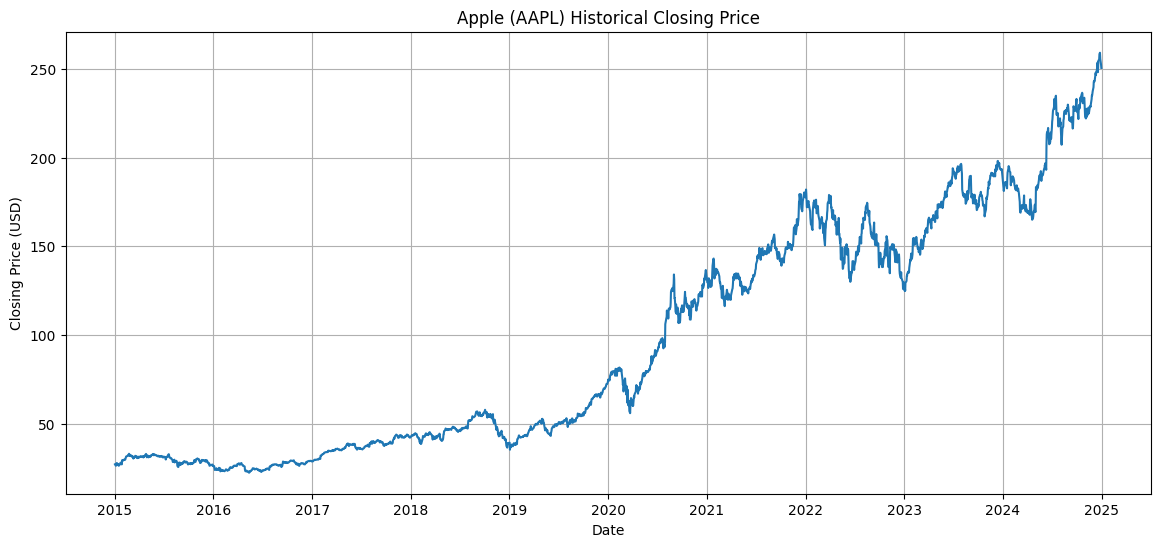

In [4]:
# Extract closing price
close_price = df["Close"]

# Plot historical closing price
plt.figure(figsize=(14, 6))
plt.plot(close_price)
plt.title("Apple (AAPL) Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.show()

In [5]:
# Convert closing prices to numpy array
data = close_price.values.reshape(-1, 1)

# Create Min-Max scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalize the data
scaled_data = scaler.fit_transform(data)

print("Original price range:")
print(data.min(), "to", data.max())

print("\nScaled price range:")
print(scaled_data.min(), "to", scaled_data.max())

Original price range:
22.584999084472656 to 259.0199890136719

Scaled price range:
0.0 to 0.9999999999999999


In [6]:
# Calculate training size
train_size = int(len(scaled_data) * 0.8)

# Split the data
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 2012
Testing samples: 504


In [7]:
# Number of previous days used to predict the next day
time_step = 60

def create_sequences(data, time_step):
    X = []
    y = []

    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

# Create training sequences
X_train, y_train = create_sequences(train_data, time_step)

# Create testing sequences
X_test, y_test = create_sequences(test_data, time_step)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1952, 60)
y_train shape: (1952,)
X_test shape: (444, 60)
y_test shape: (444,)


In [8]:
# Reshape training data
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

# Reshape testing data
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Final X_train shape: (1952, 60, 1)
Final X_test shape: (444, 60, 1)


In [9]:
# Create Sequential model
model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(time_step, 1)
    )
)

# Dropout to reduce overfitting
model.add(Dropout(0.2))

# Second LSTM layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

# Another dropout layer
model.add(Dropout(0.2))

# Fully connected output layer
model.add(Dense(1))

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [11]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0056 - val_loss: 0.0045
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 8.6909e-04 - val_loss: 0.0012
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 6.9230e-04 - val_loss: 8.8071e-04
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 6.9696e-04 - val_loss: 8.6081e-04
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - loss: 6.3820e-04 - val_loss: 0.0013
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 5.8752e-04 - val_loss: 8.4212e-04
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 5.2568e-04 - val_loss: 0.0010
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 5.8560e-04 - val_loss: 8.8796e-04
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 5.0771e-04 - val_loss: 7.7012e-04
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 5.3302e-04 - val_loss: 0.0016
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 5.6634e-04 - val_loss: 8.2341e-0

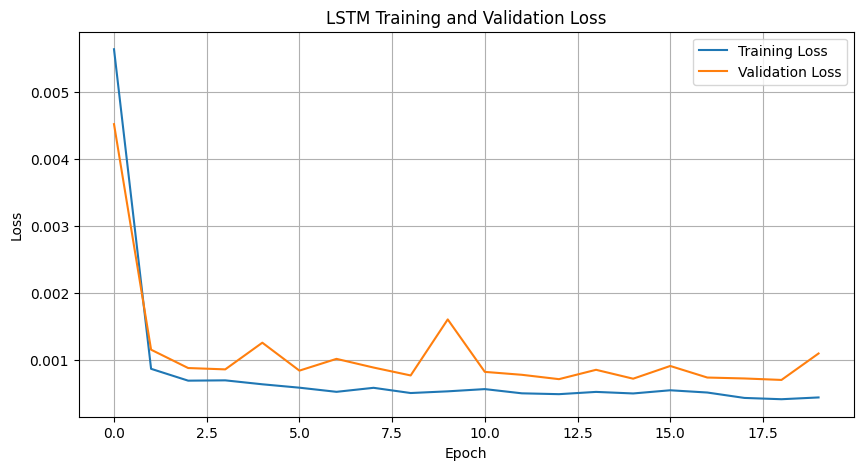

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Generate predictions
predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Prediction shape: (444, 1)


In [14]:
# Convert predictions back to original price scale
predicted_prices = scaler.inverse_transform(predictions)

# Convert actual values back to original price scale
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predicted prices:")
print(predicted_prices[:5])

print("\nActual prices:")
print(actual_prices[:5])

Predicted prices:
[[161.84937]
 [162.31842]
 [162.82927]
 [163.44397]
 [164.26842]]

Actual prices:
[[157.6499939 ]
 [160.77000427]
 [162.36000061]
 [164.8999939 ]
 [166.16999817]]


In [15]:
# Calculate Mean Squared Error
mse = mean_squared_error(
    actual_prices,
    predicted_prices
)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error
mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("Model Performance")
print("-----------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)

Model Performance
-----------------
MSE  : 30.111183500221536
RMSE : 5.487365807035425
MAE  : 4.39265235694679


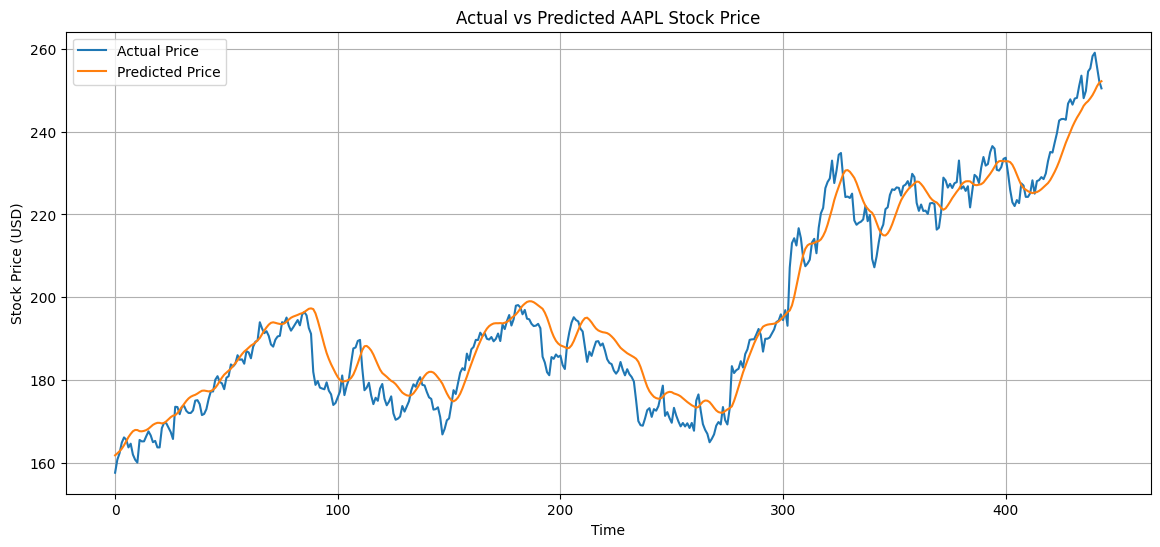

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predicted_prices,
    label="Predicted Price"
)

plt.title("Actual vs Predicted AAPL Stock Price")
plt.xlabel("Time")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
# Get the last 60 days of scaled data
last_60_days = scaled_data[-time_step:]

# Reshape for LSTM input
last_60_days = last_60_days.reshape(
    1,
    time_step,
    1
)

# Predict next day's price
next_day_prediction = model.predict(last_60_days)

# Convert prediction back to original scale
next_day_price = scaler.inverse_transform(
    next_day_prediction
)

print(
    "Predicted next closing price:",
    round(float(next_day_price[0][0]), 2),
    "USD"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted next closing price: 252.06 USD
